# SoilSpecDL

> Deep Learning modeling for soil infrared spectroscopy

**Practical deep learning for soil infrared spectroscopy, built on the fastai framework.**

`soilspecdl` brings the [fastai](https://www.fast.ai/) philosophy to soil spectroscopy: state-of-the-art deep learning models should be accessible to domain scientists, not just ML practitioners. If you are a soil scientist comfortable with R packages like `resemble` or `prospectr`, this package is designed with you in mind.

Built on top of [fastai](https://www.fast.ai/) — a library renowned for making deep learning approachable without sacrificing performance — `soilspecdl` provides sensible defaults, minimal boilerplate, and a layered API that lets you go deeper when you need to. Training a CNN on a large MIR spectral library should take a few lines of code, not a PhD in machine learning.

`soilspecdl` is part of a broader ecosystem for soil spectroscopy in Python:

- [`soilspecdata`](https://fr.anckalbi.net/soilspecdata/) — fetch and access large spectral libraries (KSSL, OSSL)
- [`soilspectfm`](https://fr.anckalbi.net/soilspectfm/) — preprocessing and spectral transforms
- **`SoilSpecDL`** — deep learning modeling

## Get Started

In [ ]:
#| eval: false
from soilspecdata.datasets.ossl import get_ossl
from soilspectfm.core import SNV, TakeDerivative
from sklearn.pipeline import Pipeline
import numpy as np

Load OSSL/USDA KSSL + ICRAF + ... dataset large soil spectroscopy library using the [SoilSpecData](https://fr.anckalbi.net/soilspecdata) python package:

In [ ]:
#| eval: false
ossl = get_ossl()
mir_data = ossl.get_mir()
wns = mir_data.wavenumbers

X, y, ids = ossl.get_aligned_data(
    spectra_data=mir_data,
    target_cols='k.ext_usda.a725_cmolc.kg')

X.shape, y.shape, ids.shape, wns[:5], wns.shape

((57676, 1701),
 (57676, 1),
 (57676,),
 array([600, 602, 604, 606, 608]),
 (1701,))

A bit of pre-processing using [SoilSpecTfm](https://fr.anckalbi.net/soilspectfm) python package:

In [ ]:
#| eval: false
pipe = Pipeline([
    ('snv', SNV()),
    ('derivative', TakeDerivative()),
])
X_tfm = pipe.fit_transform(X)

In [ ]:
#| eval: false
# Log-transforming the target (Exchangeable Potassium)
y_tfm = np.log1p(y.flatten())

In [ ]:
#| eval: false
from soilspecdl.dataloader import get_spectral_dls

Create a Fastai-like data loader with nice batch preview:

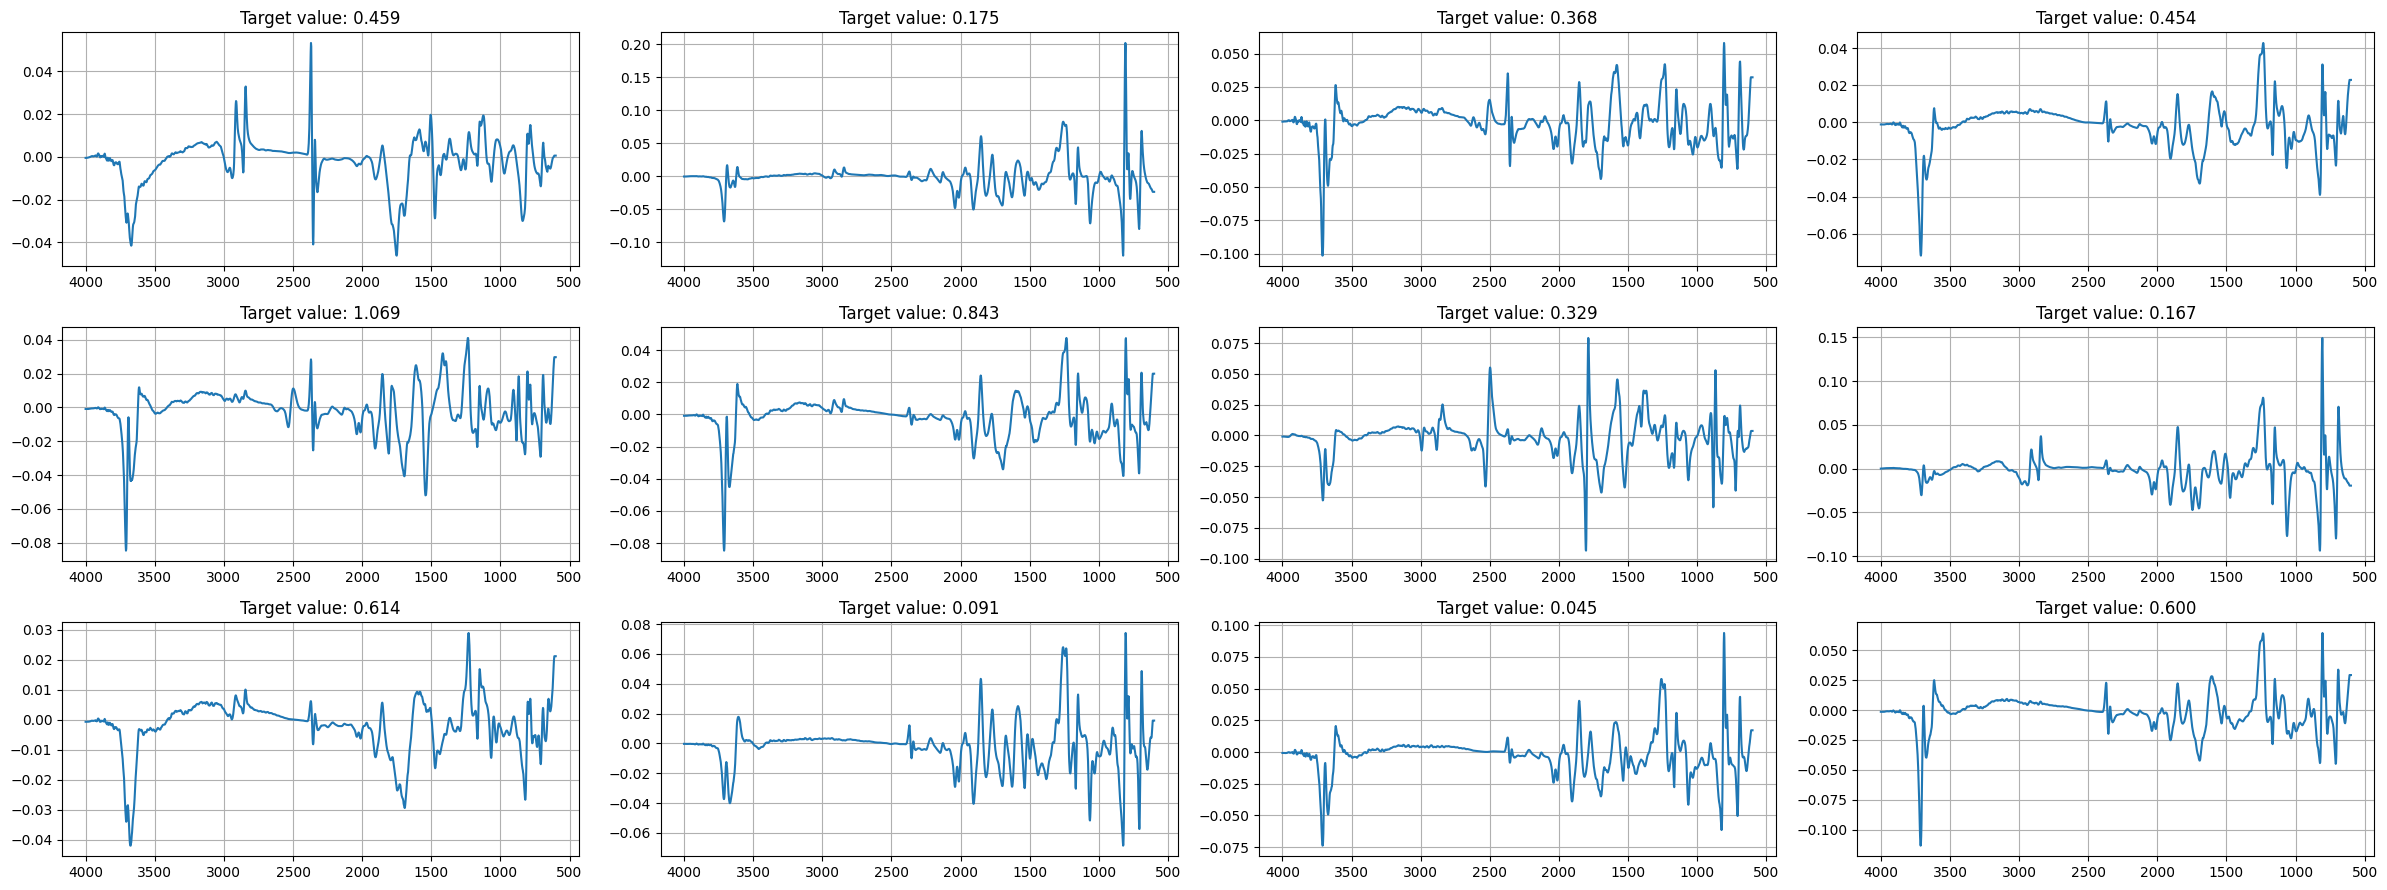

In [ ]:
#| eval: false
dls, test_idx = get_spectral_dls(X_tfm, y_tfm, wns)
dls.show_batch(max_n=12, ncols=4)

Importing [albinet et al.](https://www.sciencedirect.com/science/article/pii/S2589721722000186) paper CNN architecture, fastai Learner, ...

In [ ]:
#| eval: false
from soilspecdl.models import MirzaiCNN
from fastai.learner import Learner
from fastai.callback.schedule import lr_find
from fastai.losses import MSELossFlat
from fastai.metrics import R2Score

In [ ]:
#| eval: false
learn = Learner(dls, MirzaiCNN(), loss_func=MSELossFlat(), metrics=R2Score())

Finding "best" learning rate:

Epoch 1/1 : |█-------------------| 5.07% [73/1441 00:00<00:12... 0.2062]

SuggestedLRs(valley=0.0020892962347716093)

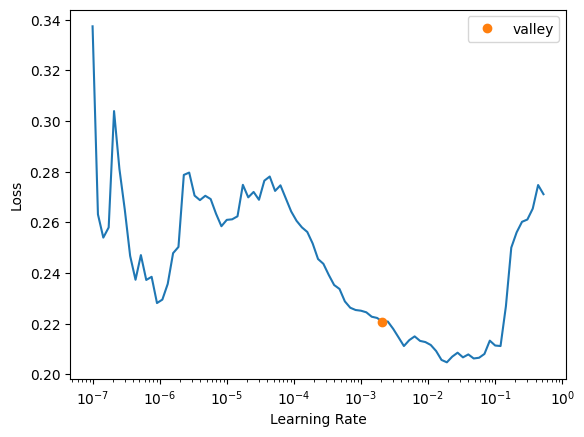

In [ ]:
#| eval: false
learn.lr_find()

In [ ]:
#| eval: false
learn.fit_one_cycle(40, lr_max=1e-3)

epoch     train_loss  valid_loss  r2_score  time    
0         0.110809    0.084269    0.394419  00:07                            
1         0.079789    0.069087    0.503516  00:15                            
2         0.074917    0.060016    0.568708  00:07                            
3         0.064447    0.064101    0.539350  00:07                            
4         0.054324    0.056243    0.595819  00:07                            
5         0.061540    0.059759    0.570552  00:06                            
6         0.057230    0.138288    0.006216  00:07                            
7         0.057897    0.121253    0.128639  00:08                            
8         0.052471    0.092067    0.338378  00:07                            
9         0.045639    0.044204    0.682335  00:15                             
10        0.048287    0.184855    -0.328426 00:06                             
11        0.043516    0.108474    0.220473  00:06                             
12      

## Developer Guide

If you are new to using `nbdev` here are some useful pointers to get you started.

### Install soilspecai in Development mode

```sh
# make sure soilspecai package is installed in development mode
$ pip install -e .

# make changes under nbs/ directory
# ...

# compile to have changes apply to soilspecai
$ nbdev_prepare
```

## Usage

### Installation

Install latest from the GitHub [repository][repo]:

```sh
$ pip install git+https://github.com/franckalbinet/soilspecdl.git
```

or from [conda][conda]

```sh
$ conda install -c franckalbinet soilspecdl
```

or from [pypi][pypi]


```sh
$ pip install soilspecdl
```


[repo]: https://github.com/franckalbinet/soilspecdl
[docs]: https://franckalbinet.github.io/soilspecdl/
[pypi]: https://pypi.org/project/soilspecdl/
[conda]: https://anaconda.org/franckalbinet/soilspecdl